In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
df_red = pd.read_csv('winequality-red.csv', sep=';')
df_white = pd.read_csv('winequality-white.csv', sep=';')

In [3]:
df_red.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [4]:
df_white.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


In [5]:
df_red.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [6]:
df_white.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


In [7]:
from sklearn.utils import resample
df_red_oversample = resample(df_red, replace=True, n_samples=len(df_white), random_state=42).reset_index(drop=True)
df_red_oversample.shape

(4898, 12)

In [8]:
df_red.shape

(1599, 12)

In [9]:
df_red_oversample.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,8.300653,0.526572,0.271143,2.551439,0.087051,15.816047,46.097183,0.996716,3.311837,0.661543,10.462012,5.645978
std,1.730988,0.177378,0.195221,1.441464,0.045575,10.502207,32.594458,0.001869,0.152422,0.173595,1.066214,0.823898
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995540,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079500,14.000000,37.000000,0.996700,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.430000,2.600000,0.090000,21.000000,62.000000,0.997800,3.400000,0.740000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [11]:
# gán nhãn cho rượu
df_white['color'] = 1
df_white.shape

(4898, 13)

In [12]:
df_red_oversample['color'] = 0
df_red_oversample.shape

(4898, 13)

In [13]:
df_wine = pd.concat([df_white, df_red_oversample], axis=0).reset_index(drop=True)
df_wine.shape

(9796, 13)

In [14]:
df_wine.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,color
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,1
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,1
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,1
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,1
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,1
5,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,1
6,6.2,0.32,0.16,7.0,0.045,30.0,136.0,0.9949,3.18,0.47,9.6,6,1
7,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,1
8,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,1
9,8.1,0.22,0.43,1.5,0.044,28.0,129.0,0.9938,3.22,0.45,11.0,6,1


In [20]:
Y = df_wine['quality'].apply(lambda x: 1 if x >= 6 else 0)                         # target
X = df_wine.drop(columns=['quality'], axis=1)   # features

In [21]:
Y.head()

,quality
0,1
1,1
2,1
3,1
4,1


In [22]:
X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,color
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,1
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,1
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,1
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,1
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,1


In [23]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [24]:
# chuẩn hóa dữ liệu
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = scaler.transform(X_test)
X_test = pd.DataFrame(X_test, columns=X.columns)

In [25]:
X_train.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,color
count,7.836000e+03,7.836000e+03,7.836000e+03,7.836000e+03,7.836000e+03,7.836000e+03,7.836000e+03,7.836000e+03,7.836000e+03,7.836000e+03,7.836000e+03,7.836000e+03
mean,3.083008e-17,-7.299476e-17,-1.704722e-16,9.929100e-17,-1.269474e-16,3.445715e-17,-1.060918e-16,1.439946e-15,-2.049294e-16,-3.173685e-16,1.228669e-15,2.176241e-17
std,1.000064e+00,1.000064e+00,1.000064e+00,1.000064e+00,1.000064e+00,1.000064e+00,1.000064e+00,1.000064e+00,1.000064e+00,1.000064e+00,1.000064e+00,1.000064e+00
min,-2.449544e+00,-1.699033e+00,-1.827006e+00,-8.969004e-01,-1.316138e+00,-1.427310e+00,-1.436483e+00,-2.920032e+00,-3.253904e+00,-2.094151e+00,-1.811674e+00,-9.916125e-01
25%,-6.373501e-01,-7.545012e-01,-5.551246e-01,-6.090773e-01,-5.721535e-01,-7.871954e-01,-9.189876e-01,-7.010613e-01,-6.824281e-01,-6.289933e-01,-8.536640e-01,-9.916125e-01
50%,-2.490230e-01,-2.297612e-01,-1.003246e-02,-4.891510e-01,-1.761617e-01,-2.052731e-01,-5.093024e-02,1.278595e-01,-7.017193e-02,-1.601427e-01,-1.569291e-01,-9.916125e-01
75%,3.981890e-01,7.147707e-01,5.956254e-01,3.503329e-01,3.158281e-01,5.512258e-01,7.336601e-01,7.057257e-01,6.645355e-01,4.259205e-01,6.268976e-01,1.008458e+00
max,5.381721e+00,6.172066e+00,5.622586e+00,1.471750e+01,1.305956e+01,1.533205e+01,5.808457e+00,1.535675e+01,4.644201e+00,8.337774e+00,3.849296e+00,1.008458e+00


In [26]:
X_test.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,color
count,1960.000000,1960.000000,1960.000000,1960.000000,1960.000000,1960.000000,1960.000000,1960.000000,1960.000000,1960.000000,1960.000000,1960.000000
mean,-0.022779,-0.036170,0.030602,0.038414,-0.051426,0.010053,0.014851,-0.044682,-0.043120,-0.047744,0.034611,0.042098
std,0.988641,0.993301,1.009521,1.028437,0.950061,0.995200,0.981612,0.990660,1.013730,0.984707,1.014161,0.999723
min,-2.190659,-1.594085,-1.827006,-0.920886,-1.388137,-1.427310,-1.436483,-2.912985,-3.131453,-1.918332,-2.160042,-0.991613
25%,-0.637350,-0.806975,-0.494559,-0.633063,-0.596153,-0.787195,-0.902294,-0.764486,-0.743654,-0.687600,-0.853664,-0.991613
50%,-0.249023,-0.334709,0.050533,-0.489151,-0.236161,-0.147081,-0.000850,0.096147,-0.070172,-0.160143,-0.156929,1.008458
75%,0.398189,0.609823,0.595625,0.428285,0.291829,0.551226,0.750353,0.688108,0.664535,0.425920,0.713989,1.008458
max,5.187557,4.860216,8.226915,4.571738,13.035565,5.410276,4.205889,2.749399,4.644201,8.337774,3.239653,1.008458


In [33]:
model = Sequential(
    [
        Dense(64, input_shape=(12,), activation='tanh'),
        Dense(32, input_shape=(12,), activation='tanh'),
        Dense(16, input_shape=(12,), activation='tanh'),
        Dense(1, activation='sigmoid')
    ]
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
model.compile(optimizer='adam', loss='mse', metrics=['accuracy'])

In [35]:
logs = model.fit(X_train, Y_train, epochs=100, batch_size=32, verbose=1)

Epoch 1/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7137 - loss: 0.1874
Epoch 2/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7546 - loss: 0.1686
Epoch 3/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7588 - loss: 0.1644
Epoch 4/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7623 - loss: 0.1622
Epoch 5/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7616 - loss: 0.1616
Epoch 6/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7823 - loss: 0.1525
Epoch 7/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7742 - loss: 0.1553
Epoch 8/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7865 - loss: 0.1500
Epoch 9/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7851 - loss: 0.1501
Epoch 10/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7951 - loss: 0.1447
Epoch 11/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7998 - loss: 0.1423
Epoch 12/100
245/245 ━━━━━━━━━━━━━━━━━━━━

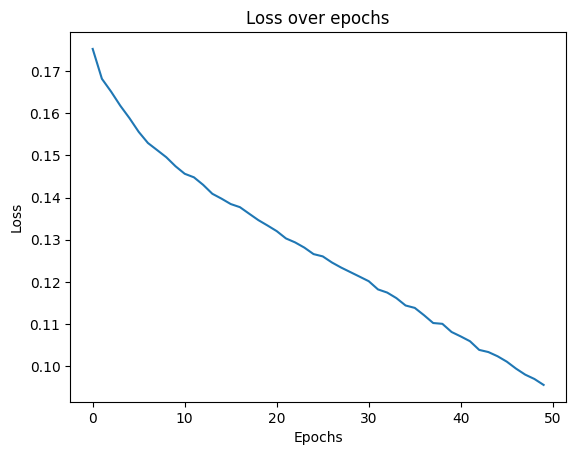

In [32]:
import matplotlib.pyplot as plt
plt.plot(logs.history['loss'])
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

In [36]:
Y_pred = model.predict(X_test)
print(Y_pred[:5])
print(Y_test[:5])

62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
[[5.6722789e-04]
 [9.8829754e-03]
 [9.9976224e-01]
 [9.5773947e-01]
 [9.9974251e-01]]
96      1
39      0
5313    1
9444    1
872     1
Name: quality, dtype: int64


In [40]:
from sklearn.metrics import accuracy_score
print('Accuracy: ', accuracy_score(Y_test, np.round(Y_pred).reshape(-1)))

Accuracy:  0.8709183673469387
